Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


100%|██████████| 1000/1000 [00:09<00:00, 105.10it/s]


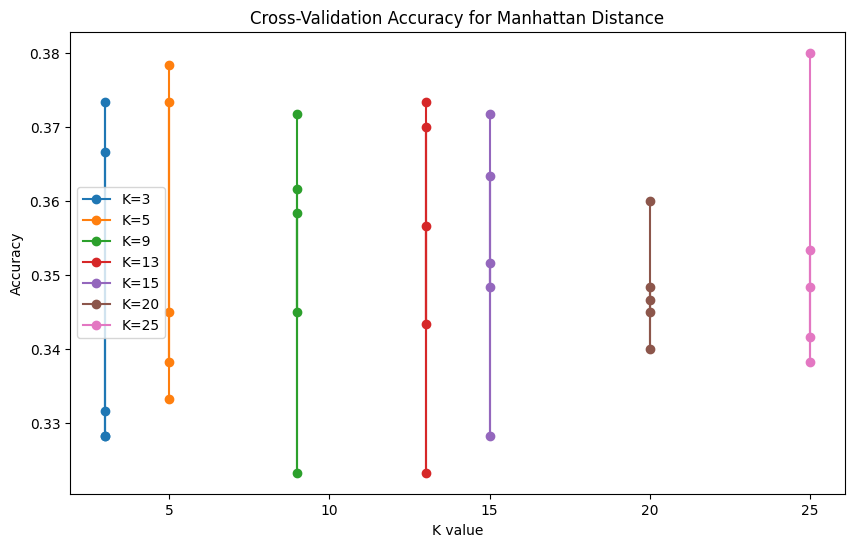

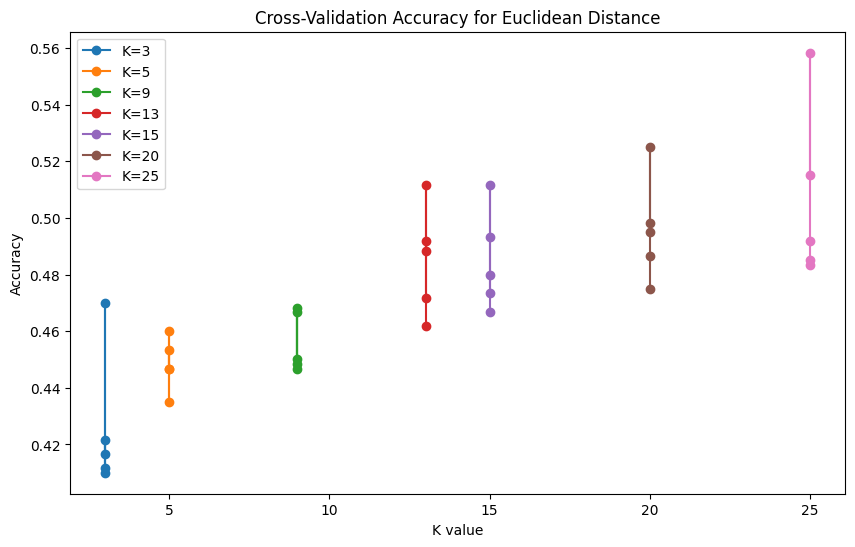

In [ ]:
from google.colab import drive
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

# Mount Google Drive
drive.mount('/content/drive')

# Define data directory
DATA_DIR = '/content/drive/MyDrive/Data_set/archive/animals/animals'

def load_images_from_folder(folder, img_size=(32, 32)):
    categories = os.listdir(folder)
    images = []
    labels = []
    for category in categories:
        category_path = os.path.join(folder, category)
        for img_name in tqdm(os.listdir(category_path)):
            img_path = os.path.join(category_path, img_name)
            try:
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, img_size)
                images.append(img)
                labels.append(categories.index(category))
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")
    return np.array(images), np.array(labels)

def flatten_images(images):
    return images.reshape(images.shape[0], -1)

def manhattan_distance(train, test):
    return np.sum(np.abs(train - test), axis=1)

def euclidean_distance(train, test):
    return np.sqrt(np.sum((train - test) ** 2, axis=1))

def knn_predict(train_data, test_data, k, distance_metric='euclidean'):
    train_images, train_labels = train_data
    test_images = test_data
    distances = []

    for test_img in test_images:
        if distance_metric == 'manhattan':
            dists = manhattan_distance(train_images, test_img)
        elif distance_metric == 'euclidean':
            dists = euclidean_distance(train_images, test_img)
        else:
            raise ValueError("Unsupported distance metric")

        distances.append(dists)

    distances = np.array(distances)
    knn_indices = np.argsort(distances, axis=1)[:, :k]
    knn_labels = np.array([train_labels[idx] for idx in knn_indices])
    predictions = [np.bincount(labels).argmax() for labels in knn_labels]

    return np.array(predictions)

def kfold_cross_validation(images, labels, k_folds=5, k_values=[3, 5, 9, 13, 15, 20, 25], distance_metrics=['manhattan', 'euclidean']):
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    results = {metric: {k: [] for k in k_values} for metric in distance_metrics}

    for train_index, val_index in kf.split(images):
        X_train, X_val = images[train_index], images[val_index]
        y_train, y_val = labels[train_index], labels[val_index]

        X_train_flat = flatten_images(X_train)
        X_val_flat = flatten_images(X_val)

        for k in k_values:
            for metric in distance_metrics:
                y_pred = knn_predict((X_train_flat, y_train), X_val_flat, k, distance_metric=metric)
                accuracy = accuracy_score(y_val, y_pred)
                results[metric][k].append(accuracy)

    return results

def plot_results(results):
    for metric, k_values in results.items():
        plt.figure(figsize=(10, 6))
        plt.title(f"Cross-Validation Accuracy for {metric.capitalize()} Distance")
        plt.xlabel("K value")
        plt.ylabel("Accuracy")
        for k, accuracies in k_values.items():
            plt.plot([k] * len(accuracies), accuracies, marker='o', linestyle='-', label=f'K={k}')
        plt.legend()
        plt.show()

# Load and preprocess images
images, labels = load_images_from_folder(DATA_DIR)
images_flat = flatten_images(images)

# Run evaluation
results = kfold_cross_validation(images_flat, labels)

# Plot results
plot_results(results)
